<a href="https://colab.research.google.com/github/1900690/pear_ripeness_analysis/blob/main/pear_rippness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#課題点と解決策の提案
Q.背景を消去してナシの果点のみを抽出するのが難しい

A.撮影条件を一定に合わせる。紙で筒を作ってその中を通して撮影することで、一定の距離かつ背景を排除することができる。
<table style="border: none; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; padding: 10px; vertical-align: top;">
      <img src="https://github.com/1900690/pear_ripeness_analysis/raw/main/images/manyual.png" width="800">
      <div style="text-align: center;">撮影方法の例</div>
    </td>
    <td style="border: none; padding: 10px; vertical-align: top;">
      <img src="https://github.com/1900690/pear_ripeness_analysis/raw/main/images/pear_sample.png" width="800">
      <div style="text-align: center;">撮影される画像の予想図</div>
    </td>
  </tr>
</table>



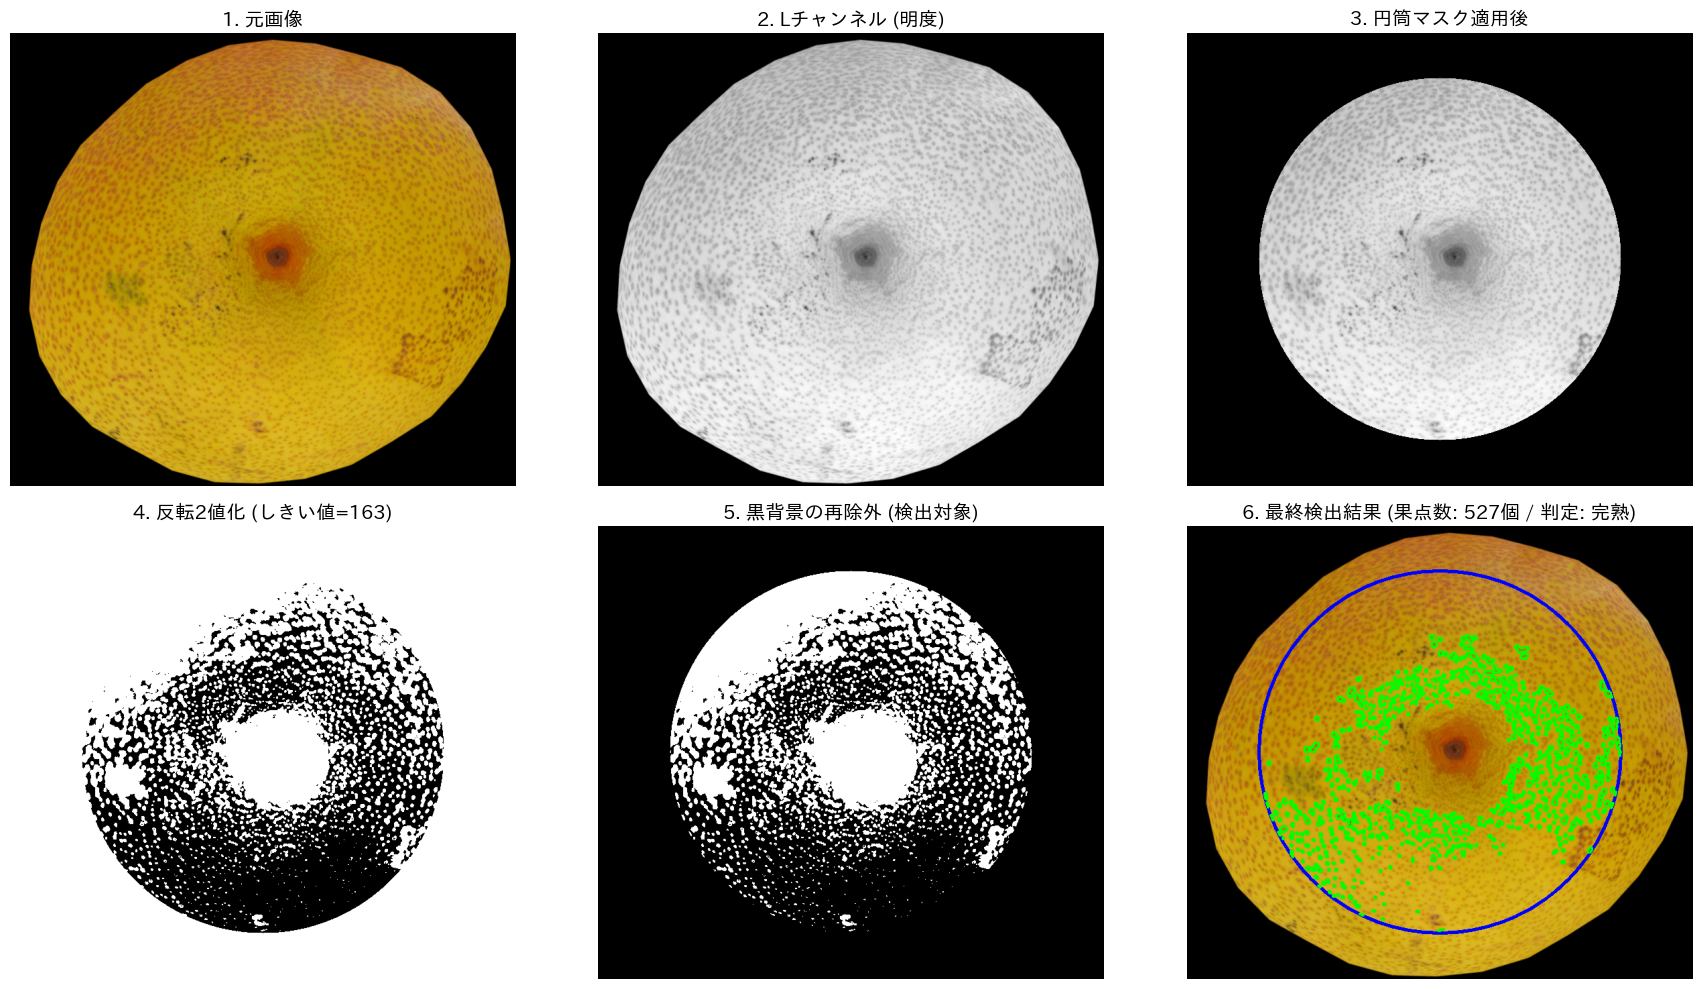

In [18]:
# グラフの日本語化ライブラリを自動インストール
!pip install -q japanize-matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import requests
from google.colab import files

# ==============================================================================
# 1. Colab フォーム設定
# ==============================================================================
#@title  ナシ果点検出・熟度分析 { run: "auto" }
入力モード = "サンプル画像を使用" #@param ["サンプル画像を使用", "自分の画像をアップロード"]
しきい値 = 163 #@param {type:"slider", min:0, max:255, step:1}
最小面積 = 5 #@param {type:"slider", min:0, max:50, step:1}
最大面積 = 150 #@param {type:"slider", min:50, max:1000, step:10}

サンプル画像URL = "https://github.com/1900690/pear_ripeness_analysis/raw/main/images/pear_sample.png"

# ==============================================================================
# 2. 状態管理 (キャッシュ)
# ==============================================================================
class ImageCache:
    def __init__(self):
        self.image_bgr = None
        self.mode = None

    def get_image(self, mode, url):
        if self.mode != mode or self.image_bgr is None:
            if mode == "サンプル画像を使用":
                print(" GitHubからサンプル画像をダウンロードしています...")
                self.image_bgr = self._download_image(url)
            else:
                print(" ナシの画像をアップロードしてください...")
                self.image_bgr = self._upload_image()
            self.mode = mode
        return self.image_bgr

    def _download_image(self, url):
        resp = requests.get(url)
        arr = np.asarray(bytearray(resp.content), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_COLOR)

    def _upload_image(self):
        uploaded = files.upload()
        if len(uploaded) == 0:
            print("画像がアップロードされませんでした。")
            return np.zeros((400, 400, 3), dtype=np.uint8)
        return cv2.imread(list(uploaded.keys())[0])

if 'image_cache' not in globals():
    image_cache = ImageCache()

# ==============================================================================
#  3. 画像処理コアロジック
# ==============================================================================
def create_circular_mask(height, width, radius_ratio=0.4):
    center_x, center_y = width // 2, height // 2
    radius = int(min(height, width) * radius_ratio)
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.circle(mask, (center_x, center_y), radius, 255, -1)
    return mask, (center_x, center_y, radius)

def process_image_pipeline(img_bgr, threshold_val, radius_ratio=0.4):
    height, width = img_bgr.shape[:2]
    mask, circle_info = create_circular_mask(height, width, radius_ratio)

    lab_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, _, _ = cv2.split(lab_img)

    masked_l_channel = cv2.bitwise_and(l_channel, l_channel, mask=mask)
    _, binarized = cv2.threshold(masked_l_channel, threshold_val, 255, cv2.THRESH_BINARY_INV)
    binarized_masked = cv2.bitwise_and(binarized, binarized, mask=mask)

    return {
        "l_channel": l_channel,
        "masked_l_channel": masked_l_channel,
        "binarized": binarized,
        "binarized_masked": binarized_masked,
        "circle_info": circle_info
    }

def analyze_and_draw_contours(img_bgr, binarized_masked, circle_info, min_area, max_area):
    contours, _ = cv2.findContours(binarized_masked, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 元画像を正しくRGBに変換
    result_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    center_x, center_y, radius = circle_info

    # RGB空間なので青は(0, 0, 255)
    cv2.circle(result_img, (center_x, center_y), radius, (0, 0, 255), 3)

    dot_count = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            dot_count += 1
            # 緑は(0, 255, 0)
            cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)

    return result_img, dot_count

# ==============================================================================
# 4. 描画・実行制御
# ==============================================================================
def get_ripeness_status(dot_count):
    if dot_count > 100: return "完熟"
    elif dot_count > 50: return "適熟"
    else: return "未熟"

def plot_debug_results(img_bgr, pipeline_results, result_img, dot_count, thresh):
    status = get_ripeness_status(dot_count)
    plt.figure(figsize=(18, 10))

    images = [
        (cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), "1. 元画像"),
        (pipeline_results["l_channel"], "2. Lチャンネル (明度)"),
        (pipeline_results["masked_l_channel"], "3. 円筒マスク適用後"),
        (pipeline_results["binarized"], f"4. 反転2値化 (しきい値={thresh})"),
        (pipeline_results["binarized_masked"], "5. 黒背景の再除外 (検出対象)"),
        (result_img, f"6. 最終検出結果 (果点数: {dot_count}個 / 判定: {status})")
    ]

    for i, (img, title) in enumerate(images, 1):
        plt.subplot(2, 3, i)
        plt.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        plt.title(title, fontsize=14)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def main():
    img_bgr = image_cache.get_image(入力モード, サンプル画像URL)
    pipeline_results = process_image_pipeline(img_bgr, しきい値)
    result_img, dot_count = analyze_and_draw_contours(
        img_bgr, pipeline_results["binarized_masked"], pipeline_results["circle_info"], 最小面積, 最大面積
    )
    plot_debug_results(img_bgr, pipeline_results, result_img, dot_count, しきい値)

if __name__ == "__main__":
    main()